# import the required libraries

In [301]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

import plotly.express as px

plt.style.use("ggplot")

In [302]:
df=pd.read_csv(f'../Data/ai_models_performance.csv')

In [303]:
df.head()

,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),400k,OpenAI,51,$4.81,100,44.29
1,Claude Opus 4.5,200k,Anthropic,49,$10.00,79,1.70
2,Gemini 3 Pro Preview (high),1m,Google,48,$4.50,128,32.19
3,GPT-5.1 (high),400k,OpenAI,47,$3.44,127,26.50
4,Gemini 3 Flash,1m,Google,46,$1.13,224,11.62


# dataset information

In [304]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 7 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Model                            188 non-null    str    
 1   Context Window                   188 non-null    str    
 2   Creator                          188 non-null    str    
 3   Intelligence Index               188 non-null    str    
 4   Price (Blended USD/1M Tokens)    188 non-null    str    
 5   Speed(median token/s)            188 non-null    int64  
 6   Latency (First Answer Chunk /s)  188 non-null    float64
dtypes: float64(1), int64(1), str(5)
memory usage: 10.4 KB


In [305]:
df.describe()

,Speed(median token/s),Latency (First Answer Chunk /s)
count,188.000000,188.000000
mean,89.765957,3.313351
std,92.515404,12.711482
min,0.000000,0.000000
25%,14.500000,0.217500
50%,72.000000,0.520000
75%,127.250000,1.082500
max,550.000000,113.010000


In [306]:
df.shape

(188, 7)

In [307]:
df.columns

Index(['Model', 'Context Window', 'Creator', 'Intelligence Index',
       'Price (Blended USD/1M Tokens)', 'Speed(median token/s)',
       'Latency (First Answer Chunk /s)'],
      dtype='str')

# check for null values

In [308]:
df.isna().sum()

Model                              0
Context Window                     0
Creator                            0
Intelligence Index                 0
Price (Blended USD/1M Tokens)      0
Speed(median token/s)              0
Latency (First Answer Chunk /s)    0
dtype: int64

# check for duplicated values

In [309]:
df.duplicated().sum()

np.int64(1)

In [310]:
df.drop_duplicates()

,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),400k,OpenAI,51,$4.81,100,44.29
1,Claude Opus 4.5,200k,Anthropic,49,$10.00,79,1.70
2,Gemini 3 Pro Preview (high),1m,Google,48,$4.50,128,32.19
3,GPT-5.1 (high),400k,OpenAI,47,$3.44,127,26.50
4,Gemini 3 Flash,1m,Google,46,$1.13,224,11.62
...,...,...,...,...,...,...,...
183,Grok Voice Agent,32k,xAI,--,$0.00,0,0.00
184,Olmo 3.1 32B Think,66k,Allen Institute for AI,--,$0.00,60,0.54
185,Cogito v2.1,128k,Deep Cogito,--,$1.25,74,0.38
186,Mi:dm K 2.5 Pro Preview,128k,Korea Telecom,--,$0.00,0,0.00


In [311]:
df.head()

,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),400k,OpenAI,51,$4.81,100,44.29
1,Claude Opus 4.5,200k,Anthropic,49,$10.00,79,1.70
2,Gemini 3 Pro Preview (high),1m,Google,48,$4.50,128,32.19
3,GPT-5.1 (high),400k,OpenAI,47,$3.44,127,26.50
4,Gemini 3 Flash,1m,Google,46,$1.13,224,11.62


In [312]:
df.dtypes

Model                                  str
Context Window                         str
Creator                                str
Intelligence Index                     str
Price (Blended USD/1M Tokens)          str
Speed(median token/s)                int64
Latency (First Answer Chunk /s)    float64
dtype: object

In [313]:
df

,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),400k,OpenAI,51,$4.81,100,44.29
1,Claude Opus 4.5,200k,Anthropic,49,$10.00,79,1.70
2,Gemini 3 Pro Preview (high),1m,Google,48,$4.50,128,32.19
3,GPT-5.1 (high),400k,OpenAI,47,$3.44,127,26.50
4,Gemini 3 Flash,1m,Google,46,$1.13,224,11.62
...,...,...,...,...,...,...,...
183,Grok Voice Agent,32k,xAI,--,$0.00,0,0.00
184,Olmo 3.1 32B Think,66k,Allen Institute for AI,--,$0.00,60,0.54
185,Cogito v2.1,128k,Deep Cogito,--,$1.25,74,0.38
186,Mi:dm K 2.5 Pro Preview,128k,Korea Telecom,--,$0.00,0,0.00


# convert the datatypes

In [314]:
df["Intelligence Index"] = pd.to_numeric(df["Intelligence Index"],errors='coerce')

In [315]:
df['Price (Blended USD/1M Tokens)']=df['Price (Blended USD/1M Tokens)'].replace(r'[$,]',"",regex=True)
df["Price (Blended USD/1M Tokens)"]=pd.to_numeric(df['Price (Blended USD/1M Tokens)'],errors="coerce")

In [316]:
df.dtypes

Model                                  str
Context Window                         str
Creator                                str
Intelligence Index                 float64
Price (Blended USD/1M Tokens)      float64
Speed(median token/s)                int64
Latency (First Answer Chunk /s)    float64
dtype: object

In [317]:
df.head()

,Model,Context Window,Creator,Intelligence Index,Price (Blended USD/1M Tokens),Speed(median token/s),Latency (First Answer Chunk /s)
0,GPT-5.2 (xhigh),400k,OpenAI,51.0,4.81,100,44.29
1,Claude Opus 4.5,200k,Anthropic,49.0,10.00,79,1.70
2,Gemini 3 Pro Preview (high),1m,Google,48.0,4.50,128,32.19
3,GPT-5.1 (high),400k,OpenAI,47.0,3.44,127,26.50
4,Gemini 3 Flash,1m,Google,46.0,1.13,224,11.62


# Feature Engineering

In [318]:
df['Price Efficiency']=df['Intelligence Index']/df['Price (Blended USD/1M Tokens)']

In [319]:
df['Speed Per Dollar']=df['Speed(median token/s)']/df['Price (Blended USD/1M Tokens)']

# Key Performance Indicators (KPI)

In [320]:
#number of unique models
df["Model"].nunique()

154

In [321]:
#number of creators or companies
df['Creator'].nunique()

37

In [322]:
#average intelligence
df['Intelligence Index'].mean()

np.float64(23.547445255474454)

In [323]:
#fastest model
df.loc[df["Speed(median token/s)"].idxmax()]

Model                              Gemini 2.5 Flash-Lite (Sep)
Context Window                                              1m
Creator                                                 Google
Intelligence Index                                        22.0
Price (Blended USD/1M Tokens)                             0.17
Speed(median token/s)                                      550
Latency (First Answer Chunk /s)                           4.22
Price Efficiency                                    129.411765
Speed Per Dollar                                   3235.294118
Name: 77, dtype: object

In [324]:
#cheapest model
df.loc[df['Price (Blended USD/1M Tokens)'].idxmin()]

Model                              KAT-Coder-Pro V1
Context Window                                 256k
Creator                                     KwaiKAT
Intelligence Index                             36.0
Price (Blended USD/1M Tokens)                   0.0
Speed(median token/s)                            62
Latency (First Answer Chunk /s)                1.09
Price Efficiency                                inf
Speed Per Dollar                                inf
Name: 22, dtype: object

In [325]:
#model with high intelligence Index
df.loc[df['Intelligence Index'].idxmax()]

Model                              GPT-5.2 (xhigh)
Context Window                                400k
Creator                                     OpenAI
Intelligence Index                            51.0
Price (Blended USD/1M Tokens)                 4.81
Speed(median token/s)                          100
Latency (First Answer Chunk /s)              44.29
Price Efficiency                         10.602911
Speed Per Dollar                         20.790021
Name: 0, dtype: object

# Data Visualizations

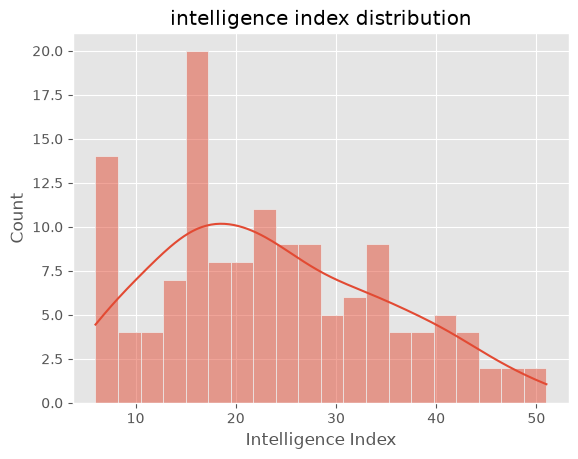

In [326]:
plt.Figure(figsize=(10,6))
sns.histplot(df['Intelligence Index'],kde=True,bins=20)
plt.title('intelligence index distribution')
plt.show()

Text(0.5, 1.0, 'distribution of price')

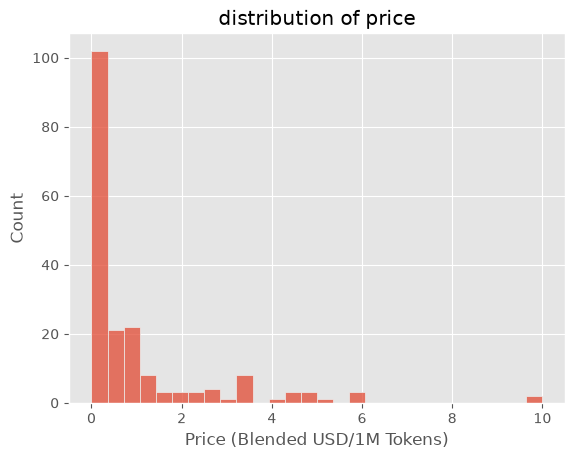

In [327]:
sns.histplot(df['Price (Blended USD/1M Tokens)'])
plt.title('distribution of price')

Text(0.5, 1.0, 'distribution of speed')

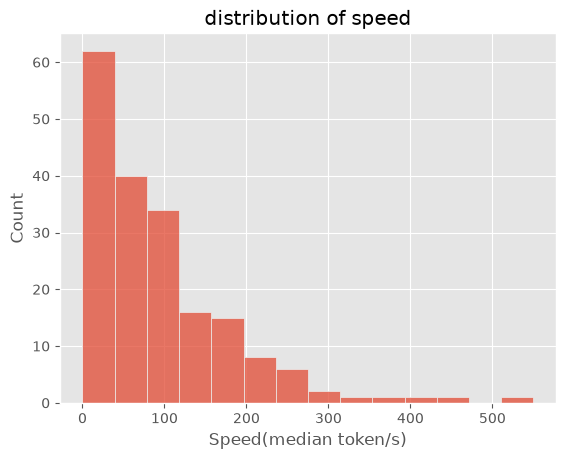

In [328]:
sns.histplot(df['Speed(median token/s)'])
plt.title('distribution of speed')

Text(0.5, 1.0, 'Latency distribution')

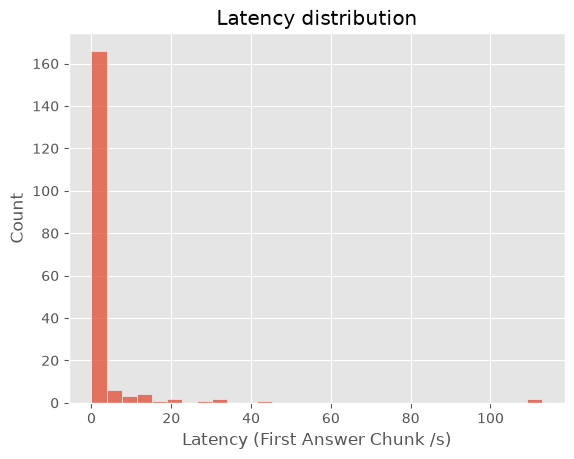

In [329]:
sns.histplot(df['Latency (First Answer Chunk /s)'],bins=30)
plt.title('Latency distribution')

<Axes: xlabel='Creator'>

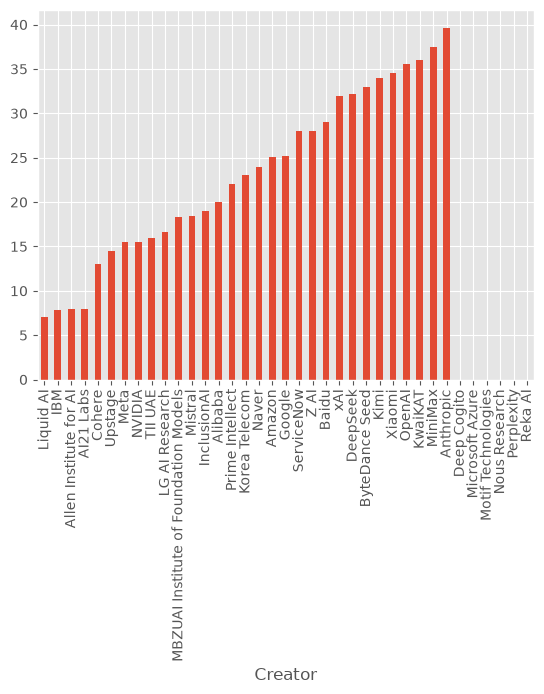

In [330]:
#Creator wise average intelligence
creator=df.groupby('Creator')['Intelligence Index'].mean().sort_values()
creator.plot(kind='bar')

<Axes: xlabel='Creator'>

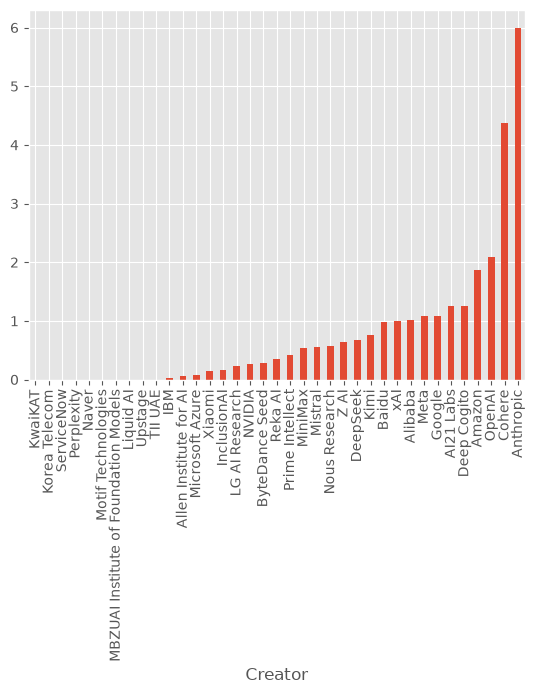

In [331]:
#creator wise average price
creator_wise_price=(df.groupby('Creator')['Price (Blended USD/1M Tokens)'].mean().sort_values())
creator_wise_price.plot(kind='bar')

<Axes: xlabel='Intelligence Index', ylabel='Model'>

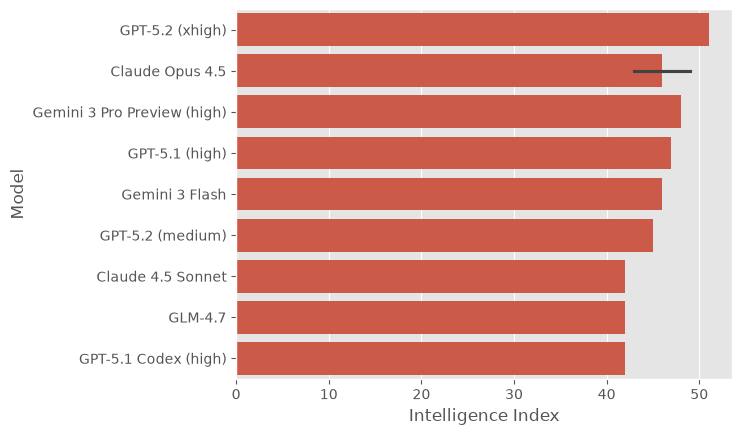

In [332]:
#top 10 smartest models
top10_intelligent=df.nlargest(10,"Intelligence Index")
sns.barplot(data=top10_intelligent,x="Intelligence Index",y='Model')

<Axes: xlabel='Speed(median token/s)', ylabel='Model'>

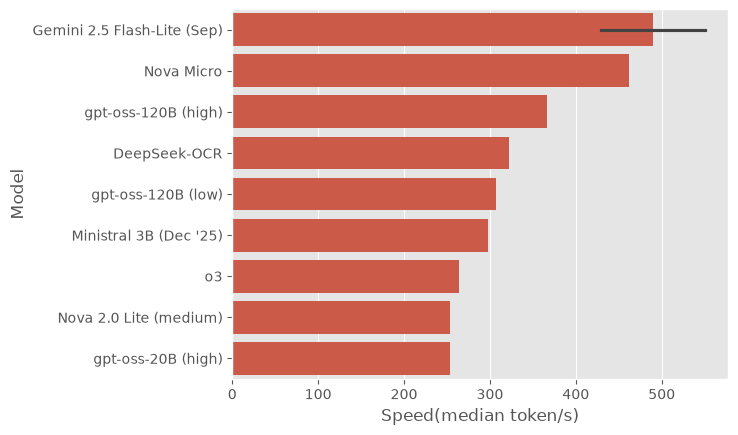

In [333]:
top10_speedest=df.nlargest(10,"Speed(median token/s)")
sns.barplot(data=top10_speedest,y="Model",x="Speed(median token/s)")

# Bivariate Analysis

<Axes: xlabel='Price (Blended USD/1M Tokens)', ylabel='Intelligence Index'>

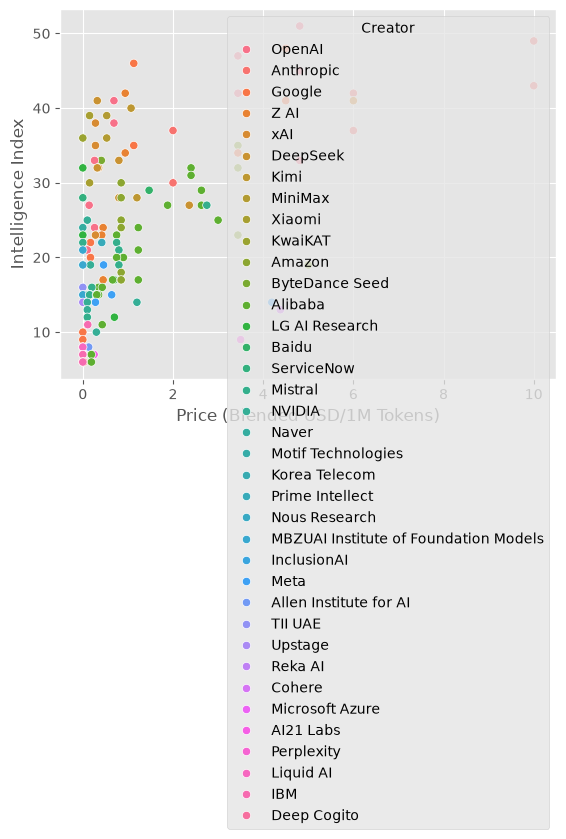

In [334]:
plt.Figure(figsize=(30,16))
sns.scatterplot(data=df,x="Price (Blended USD/1M Tokens)",y="Intelligence Index",hue="Creator")

<Axes: xlabel='Latency (First Answer Chunk /s)', ylabel='Speed(median token/s)'>

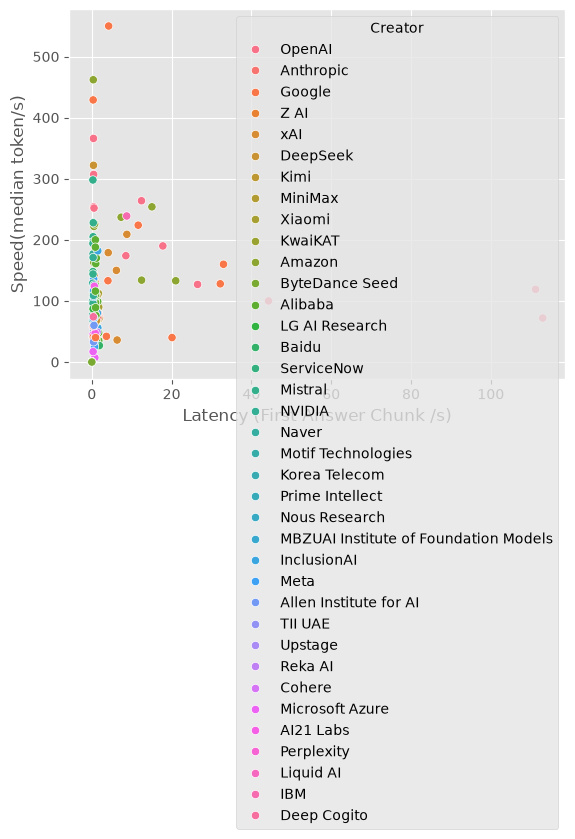

In [335]:
sns.scatterplot(data=df,x="Latency (First Answer Chunk /s)",y='Speed(median token/s)',hue='Creator')

<Axes: >

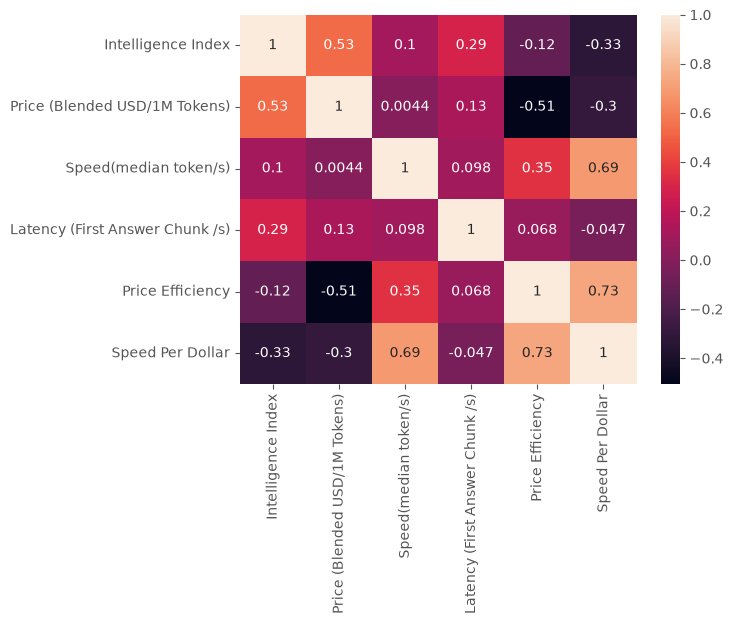

In [336]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Intelligence Index', ylabel='Creator'>

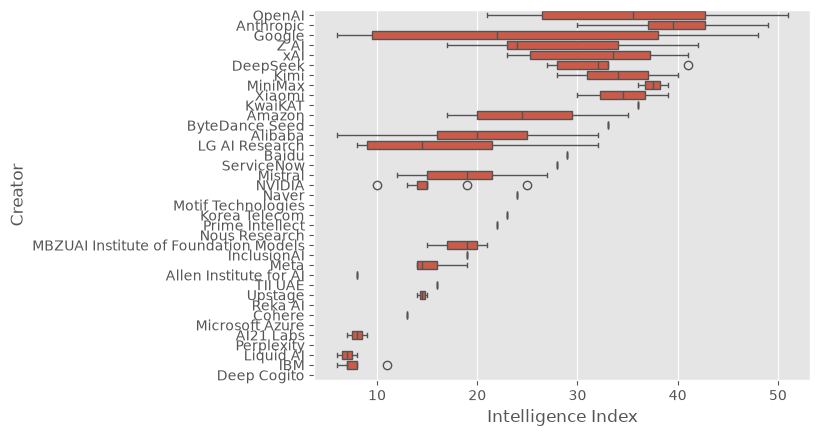

In [337]:
plt.Figure(figsize=(20,15))
sns.boxplot(data=df,y='Creator',x='Intelligence Index')

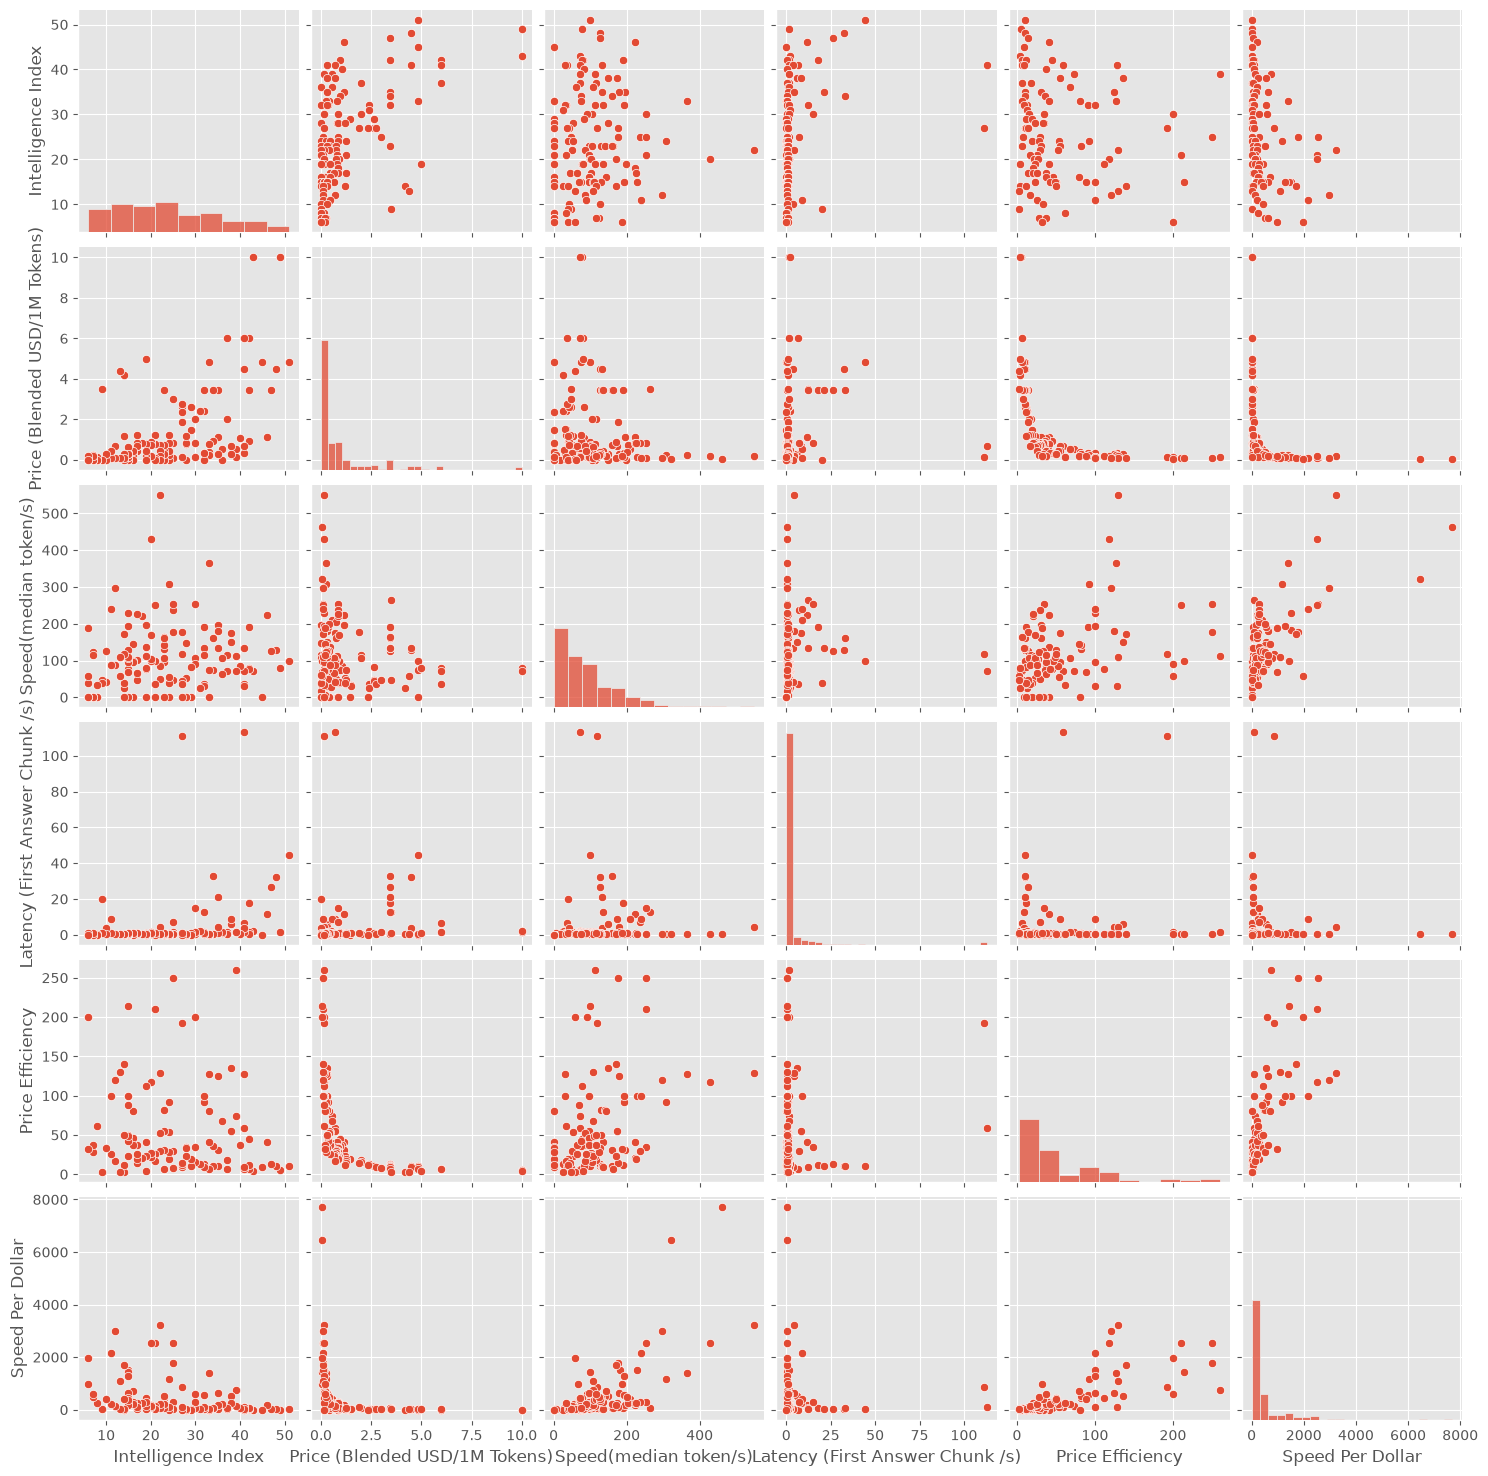

In [338]:
sns.pairplot(df.select_dtypes('number'))

# iinteractive plot

In [340]:
fig = px.scatter(
df,
x="Price (Blended USD/1M Tokens)",
y="Intelligence Index",
color="Creator",
hover_name="Model",
size="Speed(median token/s)"
)

fig.show()